In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
train_df = pd.read_csv('train.csv')

# Unnecessary columns drop kar rahe hain
X = train_df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_df['Survived']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (712, 7)
Testing shape: (179, 7)


In [3]:
# Numerical data: Age, Fare, etc. (Missing values median se bharenge aur scale karenge)
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical data: Sex, Embarked (Missing values mode se bharenge aur OHE karenge)
categorical_features = ['Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Dono ko combine karna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [4]:
# Final Pipeline setup
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
])

# Model Training
model_pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [5]:
y_pred = model_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

# Save the pipeline for task submission
joblib.dump(model_pipeline, 'titanic_model_pipeline.pkl')

Accuracy: 0.8212

Detailed Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



['titanic_model_pipeline.pkl']

In [6]:
!pip install streamlit -q

In [7]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Saved pipeline load karna
model = joblib.load('titanic_model_pipeline.pkl')

st.title("🚢 Titanic Survival Predictor")
st.write("Enter passenger details to see if they would have survived.")

# User Input Fields
col1, col2 = st.columns(2)

with col1:
    pclass = st.selectbox("Ticket Class (1st, 2nd, 3rd)", [1, 2, 3])
    sex = st.selectbox("Gender", ["male", "female"])
    age = st.slider("Age", 0, 100, 25)

with col2:
    sibsp = st.number_input("Siblings/Spouses Aboard", 0, 10, 0)
    parch = st.number_input("Parents/Children Aboard", 0, 10, 0)
    fare = st.number_input("Ticket Fare", 0.0, 600.0, 32.0)
    embarked = st.selectbox("Port of Embarkation", ["S", "C", "Q"])

# Prediction Logic
if st.button("Predict Survival"):
    input_data = pd.DataFrame([[pclass, sex, age, sibsp, parch, fare, embarked]], 
                              columns=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'])
    
    prediction = model.predict(input_data)[0]
    
    if prediction == 1:
        st.success("✨ This passenger would have SURVIVED.")
    else:
        st.error("💔 This passenger would NOT have survived.")

Writing app.py


In [ ]:
!streamlit run app.py

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, fbeta_score

# Data load karein
train_df = pd.read_csv('train.csv')

# Note: Ensure karein ke aapne model training wala cell pehle run kiya hua hai
# Agar nahi, toh 'model_pipeline' ka NameError aaye ga.

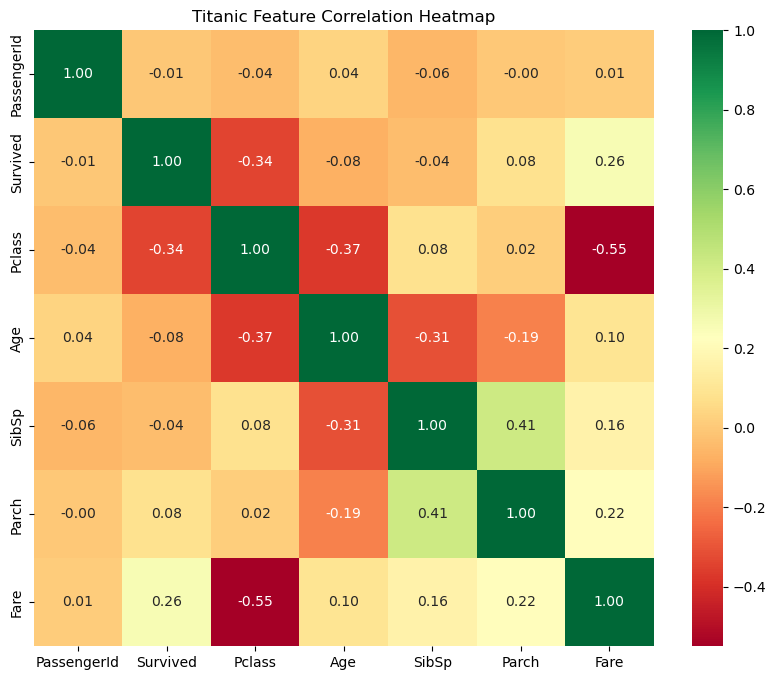

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sirf numeric columns ka correlation check karte hain
plt.figure(figsize=(10, 8))
correlation_matrix = train_df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Titanic Feature Correlation Heatmap')
plt.show()

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Data load karein
train_df = pd.read_csv('train.csv')

# Sirf zaroori columns rakhte hain
X = train_df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_df['Survived']

# 80% training aur 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into Train and Test sets!")

Data successfully split into Train and Test sets!


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Numeric columns ke liye safai aur scaling
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# 2. Categorical columns ke liye safai aur encoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Pipelines ko columns ke sath map karna
preprocessor = ColumnTransformer([
    ('num', num_pipe, ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']),
    ('cat', cat_pipe, ['Sex', 'Embarked'])
])

# 4. Final Model Pipeline banana
model_pipeline = Pipeline([
    ('prep', preprocessor), 
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 5. Model ko train karna (Isme thoda time lag sakta hai)
model_pipeline.fit(X_train, y_train)

print("Model training complete! Ab 'model_pipeline' define ho chuka hai.")

Model training complete! Ab 'model_pipeline' define ho chuka hai.


In [13]:
# Model se kahien ke wo test data par guesses (predictions) kare
y_pred = model_pipeline.predict(X_test)

print("Predictions successfully generated!")
print(f"Pehle 10 guesses: {y_pred[:10]}")

Predictions successfully generated!
Pehle 10 guesses: [0 0 0 1 0 1 1 0 1 1]


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

# Calculating individual metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# F2 Score (beta=2 focus on recall)
f2 = fbeta_score(y_test, y_pred, beta=2)

print(f"--- Professional Evaluation Report ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision:.4f} (Accuracy of positive predictions)")
print(f"Recall:    {recall:.4f} (Ability to find all survivors)")
print(f"F1-Score:  {f1:.4f} (Balance of Precision & Recall)")
print(f"F2-Score:  {f2:.4f} (Weighted towards Recall - Advanced)")

--- Professional Evaluation Report ---
Accuracy:  0.8156
Precision: 0.7971 (Accuracy of positive predictions)
Recall:    0.7432 (Ability to find all survivors)
F1-Score:  0.7692 (Balance of Precision & Recall)
F2-Score:  0.7534 (Weighted towards Recall - Advanced)


<Figure size 600x600 with 0 Axes>

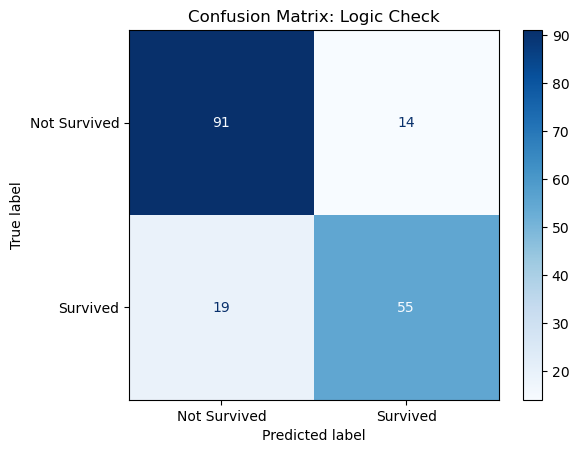

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logic Check')
plt.show()

In [16]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy:  {acc:.2f} (Overall Sahi guesses)")
print(f"Precision: {prec:.2f} (Kitne predict kiye gaye survivors waqayi bache?)")
print(f"Recall:    {rec:.2f} (Asal survivors mein se kitne model dhoond saka?)")

Accuracy:  0.82 (Overall Sahi guesses)
Precision: 0.80 (Kitne predict kiye gaye survivors waqayi bache?)
Recall:    0.74 (Asal survivors mein se kitne model dhoond saka?)


In [17]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy:  {acc:.2f} (Overall Sahi guesses)")
print(f"Precision: {prec:.2f} (Kitne predict kiye gaye survivors waqayi bache?)")
print(f"Recall:    {rec:.2f} (Asal survivors mein se kitne model dhoond saka?)")

Accuracy:  0.82 (Overall Sahi guesses)
Precision: 0.80 (Kitne predict kiye gaye survivors waqayi bache?)
Recall:    0.74 (Asal survivors mein se kitne model dhoond saka?)


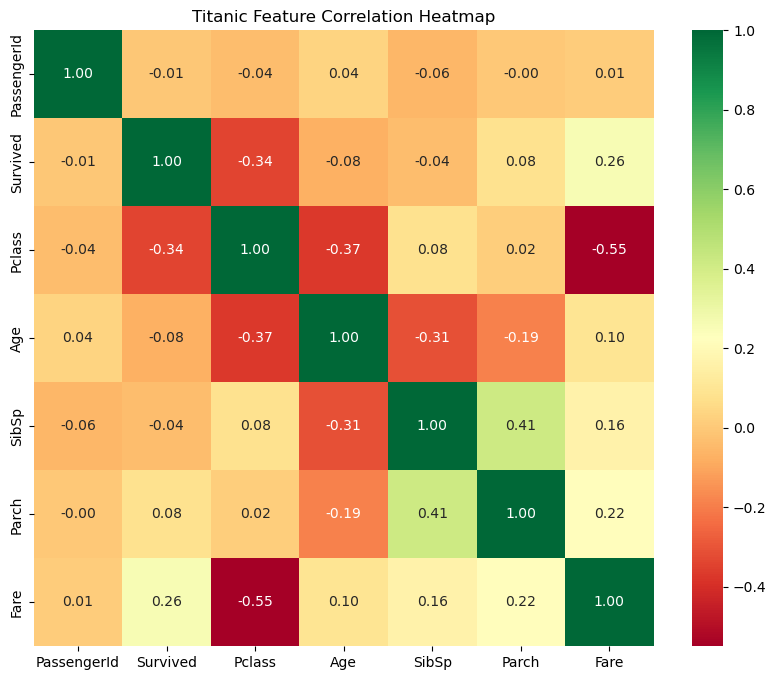

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
# Sirf numeric columns select kar rahe hain
numeric_only = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_only.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Titanic Feature Correlation Heatmap')
plt.show()